In [10]:
# Cell 1: Imports

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

from sklearn.neural_network import MLPClassifier

from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

In [11]:
# Cell 2: Load CSV

CSV_PATH = "english.csv"
BASE_IMAGE_PATH = ""   # change if images are inside another folder

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError("english.csv not found!")

df = pd.read_csv(CSV_PATH, header=None)
df.columns = ["image_path", "label"]

print("Total entries in CSV:", len(df))
df.head()

Total entries in CSV: 3411


,image_path,label
0,image,label
1,Img/img001-001.png,0
2,Img/img001-002.png,0
3,Img/img001-003.png,0
4,Img/img001-004.png,0


In [12]:
# Cell 3: Load Images

images = []
labels = []

for _, row in tqdm(df.iterrows(), total=len(df)):
    img_path = os.path.join(BASE_IMAGE_PATH, row["image_path"])

    if os.path.exists(img_path):
        try:
            img = Image.open(img_path).convert("L")
            img = img.resize((28, 28))
            img = np.array(img)

            images.append(img)
            labels.append(row["label"])
        except:
            continue

X = np.array(images)
y = np.array(labels)

print("Total images successfully loaded:", len(X))

if len(X) == 0:
    raise ValueError("No images were loaded. Check BASE_IMAGE_PATH.")

100%|██████████| 3411/3411 [00:11<00:00, 304.41it/s]

Total images successfully loaded: 3410


In [13]:
# Cell 4: Preprocessing

# Flatten
X = X.reshape(X.shape[0], -1)

# Normalize
X = X / 255.0

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Shape of X:", X.shape)
print("Number of classes:", len(np.unique(y_encoded)))

Shape of X: (3410, 784)
Number of classes: 62


In [14]:
# Cell 5: Train-Test Split

if len(X) < 10:
    raise ValueError("Dataset too small to split!")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))


Train size: 2728
Test size: 682


🔹 MODEL A — PLA (One vs Rest)

In [18]:
def step_function(z):
    return np.where(z >= 0, 1, 0)

In [19]:
class Perceptron:
    def __init__(self, lr=0.01, epochs=5):
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])
        self.bias = 0

        for _ in range(self.epochs):
            for xi, target in zip(X, y):
                linear_output = np.dot(xi, self.weights) + self.bias
                y_pred = step_function(linear_output)

                update = self.lr * (target - y_pred)
                self.weights += update * xi
                self.bias += update

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return step_function(linear_output)

In [20]:
class MultiClassPLA:
    def __init__(self, lr=0.01, epochs=5):
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):
        self.classes = np.unique(y)
        self.models = {}

        for cls in self.classes:
            print("Training class:", cls)
            y_binary = np.where(y == cls, 1, 0)

            model = Perceptron(self.lr, self.epochs)
            model.fit(X, y_binary)

            self.models[cls] = model

    def predict(self, X):
        scores = []

        for cls in self.classes:
            model = self.models[cls]
            score = np.dot(X, model.weights) + model.bias
            scores.append(score)

        scores = np.array(scores)
        return np.argmax(scores, axis=0)

In [21]:
pla = MultiClassPLA(lr=0.01, epochs=5)
pla.fit(X_train, y_train)

y_pred_pla = pla.predict(X_test)

print("PLA Accuracy:", accuracy_score(y_test, y_pred_pla))

Training class: 0
Training class: 1
Training class: 2
Training class: 3
Training class: 4
Training class: 5
Training class: 6
Training class: 7
Training class: 8
Training class: 9
Training class: 10
Training class: 11
Training class: 12
Training class: 13
Training class: 14
Training class: 15
Training class: 16
Training class: 17
Training class: 18
Training class: 19
Training class: 20
Training class: 21
Training class: 22
Training class: 23
Training class: 24
Training class: 25
Training class: 26
Training class: 27
Training class: 28
Training class: 29
Training class: 30
Training class: 31
Training class: 32
Training class: 33
Training class: 34
Training class: 35
Training class: 36
Training class: 37
Training class: 38
Training class: 39
Training class: 40
Training class: 41
Training class: 42
Training class: 43
Training class: 44
Training class: 45
Training class: 46
Training class: 47
Training class: 48
Training class: 49
Training class: 50
Training class: 51
Training class: 52
Tra

PLA creates only linear hyperplanes

Handwritten characters require nonlinear decision boundaries

MLP learns hierarchical feature representations

In [26]:
# Hyperparameter Tuning for MLP

configs = [
    ((128,), 'relu', 'sgd', 0.01, 32),
    ((256,128), 'relu', 'adam', 0.001, 64),
    ((512,256,128), 'tanh', 'adam', 0.0005, 64)
]

results = []

for hidden_layers, activation, optimizer, lr, batch in configs:

    print("\nTraining configuration:")
    print("Hidden Layers:", hidden_layers)
    print("Activation:", activation)
    print("Optimizer:", optimizer)
    print("Learning Rate:", lr)
    print("Batch Size:", batch)

    mlp = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        activation=activation,
        solver=optimizer,
        learning_rate_init=lr,
        batch_size=batch,
        max_iter=70,
        random_state=42
    )

    mlp.fit(X_train, y_train)
    y_pred = mlp.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print("Accuracy:", acc)

    results.append([
        hidden_layers,
        activation,
        optimizer,
        lr,
        batch,
        acc
    ])


Training configuration:
Hidden Layers: (128,)
Activation: relu
Optimizer: sgd
Learning Rate: 0.01
Batch Size: 32
Accuracy: 0.016129032258064516

Training configuration:
Hidden Layers: (256, 128)
Activation: relu
Optimizer: adam
Learning Rate: 0.001
Batch Size: 64
Accuracy: 0.42668621700879766

Training configuration:
Hidden Layers: (512, 256, 128)
Activation: tanh
Optimizer: adam
Learning Rate: 0.0005
Batch Size: 64
Accuracy: 0.5102639296187683


In [25]:

results_df = pd.DataFrame(
    results,
    columns=[
        "Hidden Layers",
        "Activation",
        "Optimizer",
        "Learning Rate",
        "Batch Size",
        "Accuracy"
    ]
)

results_df

,Hidden Layers,Activation,Optimizer,Learning Rate,Batch Size,Accuracy
0,"(128,)",relu,sgd,0.0100,32,0.016129
1,"(256, 128)",relu,adam,0.0010,64,0.237537
2,"(512, 256, 128)",tanh,adam,0.0005,64,0.384164


In [28]:
best_model = results_df.sort_values("Accuracy", ascending=False)
print(best_model.iloc[0])

Hidden Layers    (512, 256, 128)
Activation                  tanh
Optimizer                   adam
Learning Rate             0.0005
Batch Size                    64
Accuracy                0.384164
Name: 2, dtype: object


In [27]:
def evaluate_model(name, y_true, y_pred):
    print("\n", name)
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='macro'))
    print("Recall:", recall_score(y_true, y_pred, average='macro'))
    print("F1 Score:", f1_score(y_true, y_pred, average='macro'))

evaluate_model("PLA", y_test, y_pred_pla)
evaluate_model("MLP", y_test, y_pred_mlp)


 PLA
Accuracy: 0.09970674486803519
Precision: 0.06440088691303883
Recall: 0.09970674486803517
F1 Score: 0.0576425576102422

 MLP
Accuracy: 0.2375366568914956
Precision: 0.2755768511596967
Recall: 0.23753665689149564
F1 Score: 0.2214129519140593


In [30]:
confusion_matrix(y_test, y_pred_mlp)

array([[2, 0, 0, ..., 0, 0, 0],
       [0, 3, 0, ..., 0, 0, 0],
       [0, 0, 2, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 2, 1, 0],
       [0, 0, 0, ..., 1, 1, 0]], shape=(62, 62))

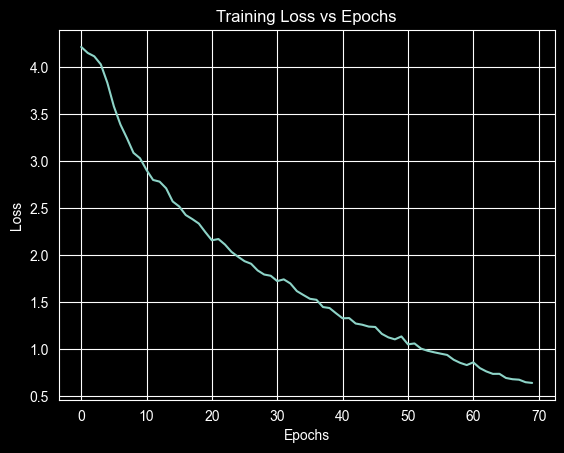

In [29]:
plt.plot(mlp.loss_curve_)
plt.title("Training Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()